# Officina 001: Material Correspondence

This iteration runs the production generation, page drawing, synthetic handwriting, reading and continuation functions through one game. The household and replies are synthetic. Cloud calls incur usage. No physical printer, camera, deployed HTTP API, parent approval or household clock is exercised. Declared minutes are document timings, not measured human time.

Acceptance requires an explicit close, multiple written returns and generated sheets, at most five sheets, a continuation receiving the returned descriptions, and an untouched-page control read as blank. Repeated continuations still receive the original approved plan, as in the current hub; the record must reveal any limitation this causes.

In [1]:
from __future__ import annotations

import importlib
import io
import json
import os
import subprocess
import sys
import time
from datetime import UTC, datetime
from pathlib import Path

from IPython.display import Image, Markdown, display
from PIL import Image as Picture

START = Path.cwd().resolve()
ROOT = next(
    candidate for candidate in (START, *START.parents)
    if (candidate / 'pyproject.toml').is_file() and (candidate / 'research').is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
bench = importlib.import_module('research.bench')
settings = bench.environment()
FINGERPRINT = bench.reload_prompts()
ITERATION = '001-material-correspondence'
RUN = ROOT / 'officina' / 'runs' / (
    ITERATION + '-' + datetime.now(UTC).strftime('%Y%m%dT%H%M%S%fZ')
)
print('Interpreter:', sys.executable)
print('Prompt fingerprint:', FINGERPRINT)
print('Artifacts:', RUN.relative_to(ROOT))
print('Cloud configuration loaded; credentials are not displayed.')

Interpreter: C:\code\lanternina\.venv\Scripts\python.exe
Prompt fingerprint: c5bd47db6781
Artifacts: officina\runs\001-material-correspondence-20260915T131106126755Z
Cloud configuration loaded; credentials are not displayed.


## Synthetic Household

The game alternates printed messages and written replies. Each sheet supplies the instructions and material needed for its exchange. The ceiling includes any closing print.

In [2]:
from panel.preferences import DEFAULT_SHEETS
from research.households import Household, Memory, arguments

HOUSE = Household(
    name='officina-001-synthetic', interests=('le mappe', 'i luoghi inventati'),
    avoid=('la guerra',), sheets=DEFAULT_SHEETS,
)
ARGS = arguments(HOUSE, Memory())
ARGS['brief'] = (
    'Un gioco di corrispondenza materiale: costruire insieme la mappa di un luogo inventato. '
    'Lanternina invia stampe e messaggi sui display; il ragazzo risponde scrivendo o '
    'disegnando sui fogli e fotografando il lavoro. Distribuisci nuovi fogli lungo almeno '
    'tre scambi significativi, senza consegnarli tutti insieme. Ogni risposta usa un '
    'dettaglio della precedente e lascia qualcosa di concreto da aggiungere. Prevedi '
    'ask quando serve leggere il contenuto per decidere la risposta. Arriva a una '
    'chiusura esplicita sul lavoro realizzato. Il massimo per tutto il gioco e i seguiti '
    'e di cinque fogli, compresa una eventuale stampa finale. Le attese dipendono da '
    'lettura, stampa e aggiornamento del display; non promettere risposte immediate. '
    'Tutte le informazioni per agire devono essere sulla carta o nei messaggi. '
    'Tutto il materiale e sintetico.'
)
print('Sheet ceiling:', ARGS['sheets'])
print(ARGS['brief'])

Sheet ceiling: 5
Un gioco di corrispondenza materiale: costruire insieme la mappa di un luogo inventato. Lanternina invia stampe e messaggi sui display; il ragazzo risponde scrivendo o disegnando sui fogli e fotografando il lavoro. Distribuisci nuovi fogli lungo almeno tre scambi significativi, senza consegnarli tutti insieme. Ogni risposta usa un dettaglio della precedente e lascia qualcosa di concreto da aggiungere. Prevedi ask quando serve leggere il contenuto per decidere la risposta. Arriva a una chiusura esplicita sul lavoro realizzato. Il massimo per tutto il gioco e i seguiti e di cinque fogli, compresa una eventuale stampa finale. Le attese dipendono da lettura, stampa e aggiornamento del display; non promettere risposte immediate. Tutte le informazioni per agire devono essere sulla carta o nei messaggi. Tutto il materiale e sintetico.


## Local Checks

These tests exercise the simulator and handwriting helpers without cloud models. They distinguish a conclusion from a stop, degraded reading or failed print. They do not validate a physical game.

In [3]:
test_environment = {
    key: value for key, value in os.environ.items()
    if not (key.startswith('LANTERNINA_') and
            any(part in key for part in ('FOUNDRY', 'CONTENT_SAFETY', 'SAFETY')))
}
began = time.perf_counter()
checked = subprocess.run(
    [sys.executable, '-m', 'pytest', 'tests/test_workbench.py',
     'tests/test_handwriting.py', '-q'],
    env=test_environment, capture_output=True, text=True, encoding='utf-8',
)
print(checked.stdout)
print(checked.stderr)
print(f'Elapsed: {time.perf_counter() - began:.1f} s')
checked.check_returncode()

................                                                         [100%]
16 passed in 4.62s


Elapsed: 6.3 s


## The Complete Game

This cell calls paid services and keeps logical prompts, responses, generated sheets and synthetic returns in the run directory. Images below are reduced previews; full-size images remain in the artifacts. The simulator advances non-collection moments immediately and does not reproduce display latency. Its step limit reports interruption, never success.


--- SENT: choosing what to build an afternoon out of ---
You are about to devise one activity for one adolescent to spend at home. First you are choosing what to build it out of.

Below is a catalogue of methods that work on paper, filtered to the ones this house can actually run. Each line is an id and a name. Some are marked as a move: a move is not something to do on its own — it is applied to a form and changes what the form asks of somebody.

The parent wrote down these interests, as a place to begin: ["le mappe", "i luoghi inventati"]
And these things to keep away from: ["la guerra"]
Activities already offered here: []
How the activity should be pitched: nothing is known about this house yet

Choose one form and one move. Choose what would make the best activity for this house — not what is easiest to write, and not the first one that looks familiar. If the interests point at something, let them; if nothing fits them, choose the form that would make the strangest good activity r

--- RETURNED: choosing what to build an afternoon out of (16.279 s) ---


{"form":"label-every-line-you-draw","move":"one-fact-that-changes-what-was-already-read","why":"An invented map gains meaning through its connections, then one new fact transforms how the whole place is understood."}



--- SENT: devising an afternoon ---
You are making one activity for one adolescent to spend at home, mostly on their own. The household capabilities below say which displays, printing and return channels are available. A handheld camera can show Lanternina the work that has been made, including paper when sheet reading is enabled. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this activity actually is. Nothing here is set in stone either — an activity can turn out differently once it has started, and that is ordinary rather than a failure.

An activity is a good one when these things are true of it.

Somebody can

--- RETURNED: devising an afternoon (98.7 s) ---


...

[1] say: La carta è incompleta


[2] hand_over: I Nove Margini



--- SENT: drawing a map ---
The page is a hand-drawn map, the kind folded into the back of an old book: a border, a coastline or paths, and small symbols for places.

Letter this large, as the title: "Carta dei Nove Margini"
Letter this smaller, under the title: "Lanterna spenta; serra aperta; ponte cieco; pozzo sonoro; archivio umido; scala tronca; forno freddo; cortile obliquo; osservatorio scoperto. Unisci le figure: una linea da ciascuna. Etichetta ogni linea con due parole; cerchia il più solo; rimanda."
Leave three ruled lines, with "Il luogo meno collegato, perché" lettered above it

What the drawing on the page shows: A clean top-down imaginary map with nine widely separated, simple landmarks and ample white space between them: an unlit lantern on a stone base, an open greenhouse, a bridge ending at a wall, a round well, a low archive building, a broken staircase, a cold oven, a slanted courtyard, and a roofless observatory. No paths or connecting lines. Strong black outlines 

--- RETURNED: drawing a map (47.205 s) ---


<1295468 bytes>


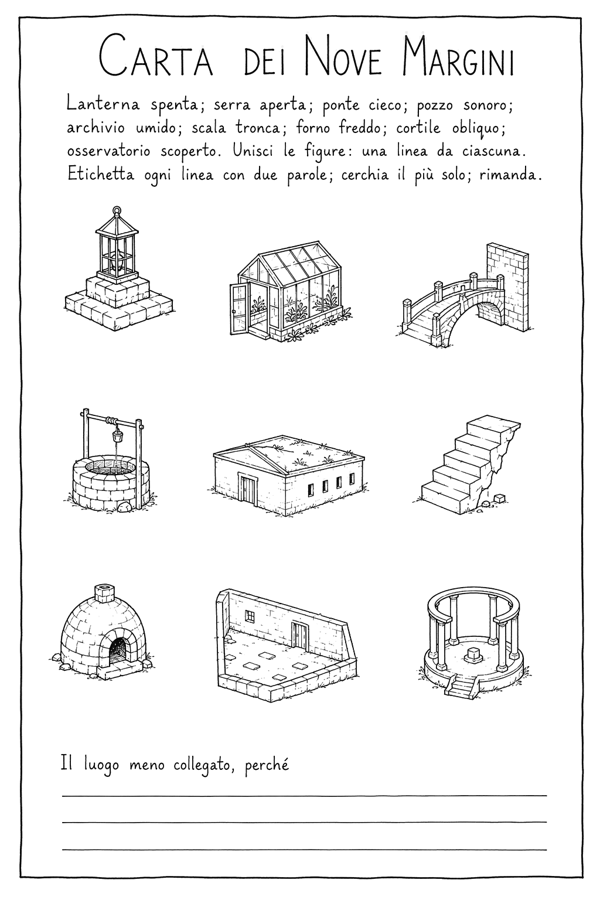

[3] collect: La carta può tornare



--- SENT: synthetic handwriting ---
The same sheet of paper, now filled in by a teenager with a blue ballpoint pen: untidy, slanted, not always on the line, a word crossed out somewhere.
Answer what the page asks, in Italian, briefly and in your own words — the way somebody of thirteen would, not the way a form would. Where there is a box to draw in, draw something rough.
Change nothing that is already printed on the page: not the title, not the lines, not the drawing. Add only what a person would have added, and leave the paper the same size.


--- RETURNED: synthetic handwriting (43.903 s) ---


<1125692 bytes>


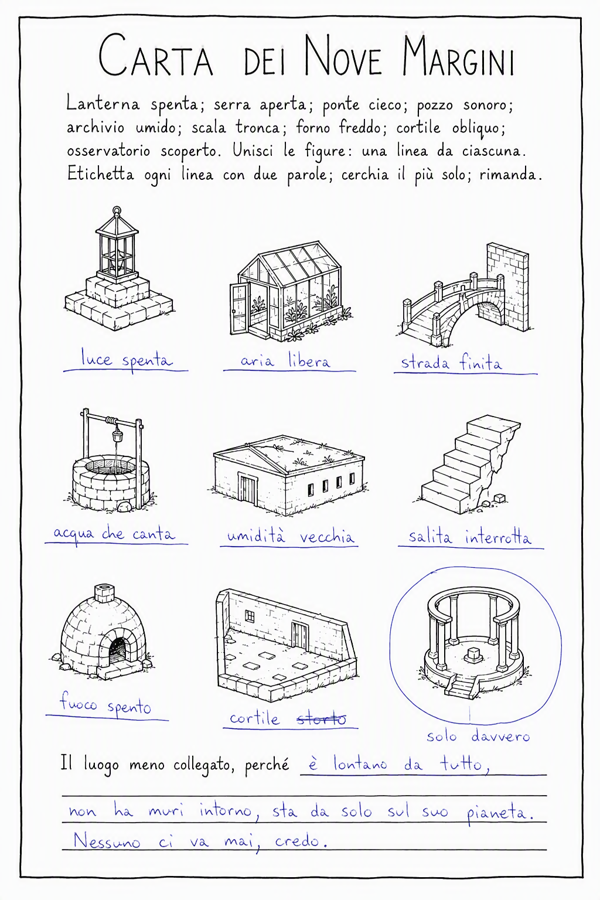


--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (10.677 s) ---


{"written":true,"same_sheet":true,"describes":["Underlined blue labels under the top row: “luce spenta”, “aria libera”, “strada finita”","Underlined blue labels under the middle row: “acqua che canta”, “umidità vecchia”, “salita interrotta”","Underlined blue label “fuoco spento” beneath the oven","Blue label “cortile storto” beneath the courtyard, with “storto” crossed out","A large blue circle around the observatory, linked to the label “solo davvero”","Blue text on the final lines: “è lontano da tutto, non ha muri intorno, sta da solo sul suo pianeta.”","Blue text on the last line: “Nessuno ci va mai, credo.”"]}



--- SENT: continuing aftn-e92c6455 after map-return ---
You are writing the rest of an activity in one household. It was planned this far and the plan says the rest depends on what came back on paper.
Answer with JSON and nothing else, in this exact shape:
{"moments": [ ... ]}
Which activity this is and which moment it follows are known already and are not yours to write.
Every moment, whatever it does, carries these five keys and then whatever its act adds:
  "id": 2 to 32 characters of lowercase a-z, digits and hyphens. No capitals, no accented letters, no underscores and no spaces. Ids are never shown to anybody, so write them in English even when the activity is not.
  "heading": at most 28 characters, on the display.
  "weights": {"short": W, "standard": W, "extended": W} — the same moment at three costs, reaching the same point in the story. W is {"minutes": <whole number>, "lines": [a list of at most 4 lines, each at most 44 characters]}. The short one takes about a third of th

--- RETURNED: continuing aftn-e92c6455 after map-return (55.862 s) ---


<4704 bytes>


[4] hand_over: La frase diventa confine



--- SENT: drawing a notebook ---
The page is a leaf out of a field notebook: a margin rule down the left and a quick sketch in one corner. Rule lines only where the page asks for something to be written, and leave the paper plain everywhere else.

Letter this large, as the title: "La regola emersa"
Letter this smaller, under the title: "La carta dice «solo davvero»: ora quelle parole nominano un confine. Sulla Carta, chiudi una linea attorno all’osservatorio; copiala qui. Scegli un altro luogo e scrivi cosa cambia dal suo lato del confine. Rimanda questo foglio con copia, luogo e conseguenza visibili."
Leave an empty box about a third of the page high, to draw in, with "Copia del confine" lettered above it
Leave one ruled line, long enough for a few words, with "Luogo dall’altro lato" lettered above it
Leave three ruled lines, with "Conseguenza del confine" lettered above it

What the drawing on the page shows: A small roofless observatory seen from above in a wide empty area, with ei

--- RETURNED: drawing a notebook (40.301 s) ---


<906480 bytes>


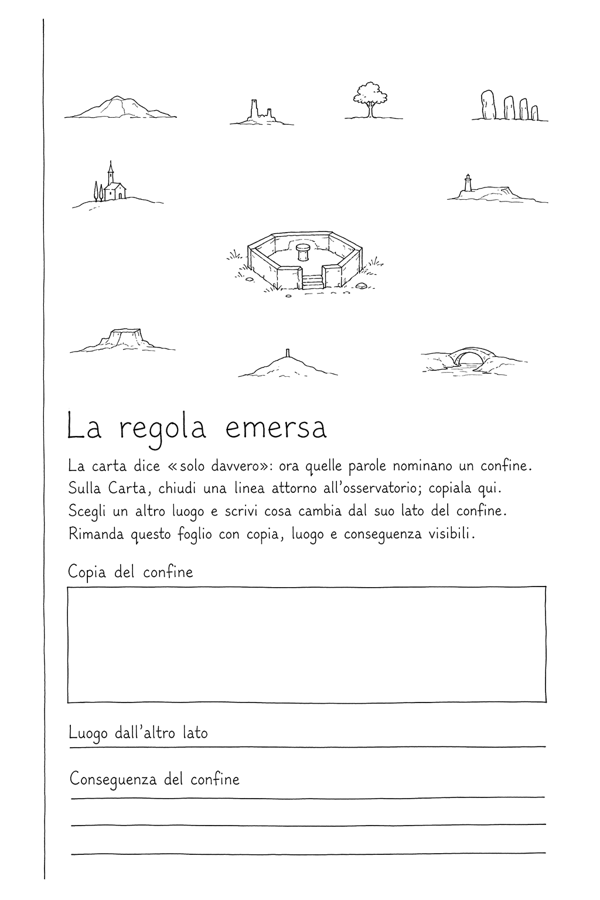

[5] collect: Il confine può tornare



--- SENT: synthetic handwriting ---
The same sheet of paper, now filled in by a teenager with a blue ballpoint pen: untidy, slanted, not always on the line, a word crossed out somewhere.
Answer what the page asks, in Italian, briefly and in your own words — the way somebody of thirteen would, not the way a form would. Where there is a box to draw in, draw something rough.
Change nothing that is already printed on the page: not the title, not the lines, not the drawing. Add only what a person would have added, and leave the paper the same size.
Write only on the FIRST image. The other 1 images are sheets already on the table. Use their content when the first sheet refers to them. Return only the first sheet, with the added handwriting.


--- RETURNED: synthetic handwriting (46.931 s) ---


<775241 bytes>


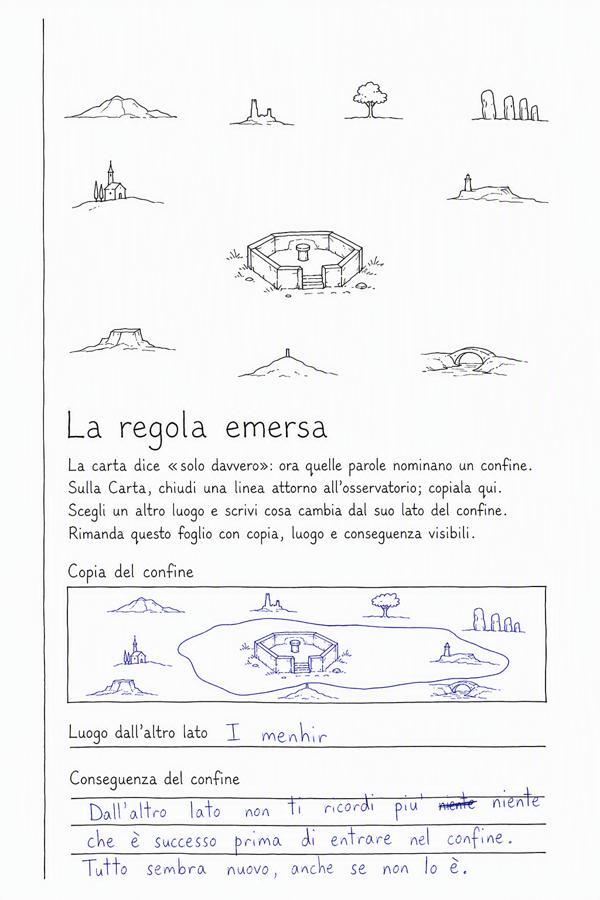


--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (6.696 s) ---


{"written":true,"same_sheet":true,"describes":["blue copies of the nine landmarks and central observatory in the large box","an irregular blue closed line around the observatory in the large box","“I menhir” written on the “Luogo dall’altro lato” line","three lines under “Conseguenza del confine” about forgetting what happened before entering the boundary","one crossed-out word before “niente” on the first consequence line"]}



--- SENT: continuing aftn-e92c6455 after boundary-return ---
You are writing the rest of an activity in one household. It was planned this far and the plan says the rest depends on what came back on paper.
Answer with JSON and nothing else, in this exact shape:
{"moments": [ ... ]}
Which activity this is and which moment it follows are known already and are not yours to write.
Every moment, whatever it does, carries these five keys and then whatever its act adds:
  "id": 2 to 32 characters of lowercase a-z, digits and hyphens. No capitals, no accented letters, no underscores and no spaces. Ids are never shown to anybody, so write them in English even when the activity is not.
  "heading": at most 28 characters, on the display.
  "weights": {"short": W, "standard": W, "extended": W} — the same moment at three costs, reaching the same point in the story. W is {"minutes": <whole number>, "lines": [a list of at most 4 lines, each at most 44 characters]}. The short one takes about a third 

--- RETURNED: continuing aftn-e92c6455 after boundary-return (52.961 s) ---


<5724 bytes>


[6] hand_over: Oltre il tratto blu



--- SENT: drawing a dossier ---
The page is a file card out of somebody's archive: a heading with a rule under it, a specimen drawn to one side, and a few ruled lines beside it. Never a grid, never a table, never a box for every answer.

Letter this large, as the title: "I menhir oltre il confine"
Letter this smaller, under the title: "Il confine chiuso intorno all'osservatorio conduce a I menhir. Oltre la linea si dimentica ciò che è accaduto prima di entrare. Disegna un emblema e scrivi una regola locale negli spazi. Rimanda il dossier con entrambi gli spazi visibili."
Leave an empty box about a third of the page high, to draw in, with "Emblema di I menhir" lettered above it
Leave three ruled lines, with "Regola locale di I menhir" lettered above it

What the drawing on the page shows: A distant roofless observatory seen from above, enclosed by an irregular closed line. Beyond the line lies a sparse fictional landscape with three plain upright stones. Strong black outlines and ample

--- RETURNED: drawing a dossier (27.179 s) ---


<976424 bytes>


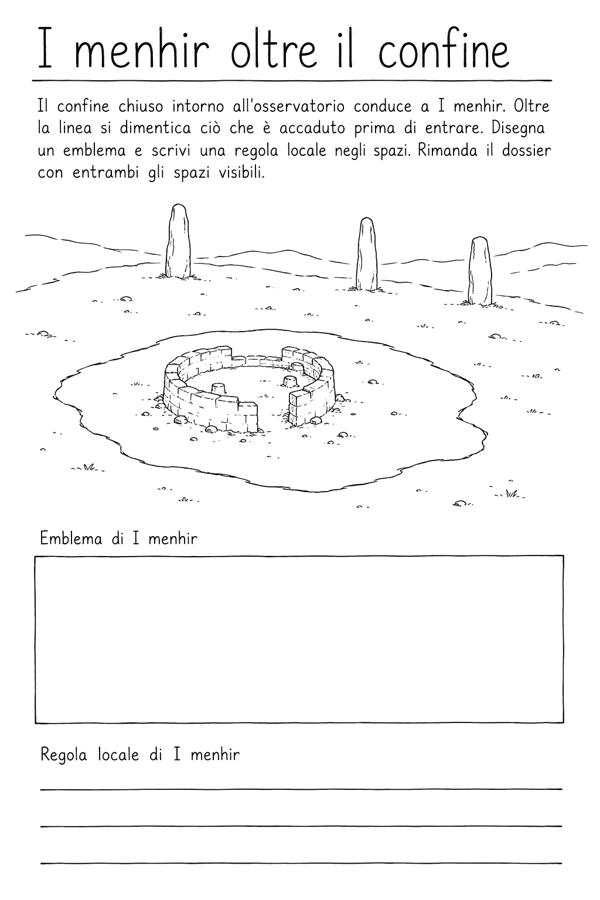

[7] collect: Il dossier può tornare



--- SENT: synthetic handwriting ---
The same sheet of paper, now filled in by a teenager with a blue ballpoint pen: untidy, slanted, not always on the line, a word crossed out somewhere.
Answer what the page asks, in Italian, briefly and in your own words — the way somebody of thirteen would, not the way a form would. Where there is a box to draw in, draw something rough.
Change nothing that is already printed on the page: not the title, not the lines, not the drawing. Add only what a person would have added, and leave the paper the same size.
Write only on the FIRST image. The other 2 images are sheets already on the table. Use their content when the first sheet refers to them. Return only the first sheet, with the added handwriting.


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x000001731697C550>


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x000001731697ED50>


--- RETURNED: synthetic handwriting (45.416 s) ---


<874760 bytes>


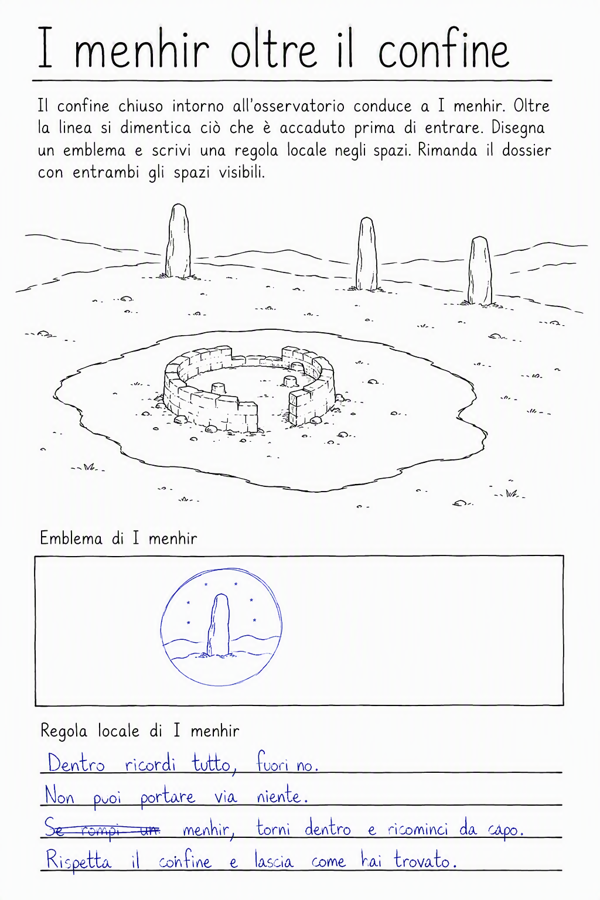


--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (5.226 s) ---


{"written":true,"same_sheet":true,"describes":["A blue circular emblem with a standing stone, hills and seven stars in the emblem box","“Dentro ricordi tutto, fuori no.” on the first rule line","“Non puoi portare via niente.” on the second rule line","Crossed-out words “Se rompi un” at the start of the third rule line","“menhir, torni dentro e ricominci da capo.” on the third rule line","“Rispetta il confine e lascia come hai trovato.” on the fourth rule line"]}



--- SENT: continuing aftn-e92c6455 after emblem-return ---
You are writing the rest of an activity in one household. It was planned this far and the plan says the rest depends on what came back on paper.
Answer with JSON and nothing else, in this exact shape:
{"moments": [ ... ]}
Which activity this is and which moment it follows are known already and are not yours to write.
Every moment, whatever it does, carries these five keys and then whatever its act adds:
  "id": 2 to 32 characters of lowercase a-z, digits and hyphens. No capitals, no accented letters, no underscores and no spaces. Ids are never shown to anybody, so write them in English even when the activity is not.
  "heading": at most 28 characters, on the display.
  "weights": {"short": W, "standard": W, "extended": W} — the same moment at three costs, reaching the same point in the story. W is {"minutes": <whole number>, "lines": [a list of at most 4 lines, each at most 44 characters]}. The short one takes about a third of

--- RETURNED: continuing aftn-e92c6455 after emblem-return (47.434 s) ---


<6602 bytes>


[8] hand_over: Sette stelle sul margine



--- SENT: drawing a label ---
The page is what a museum puts beside one object: the object drawn large and alone in the upper half, a short caption under it, and a great deal of empty paper.

Letter this large, as the title: "Il confine delle sette stelle"
Letter this smaller, under the title: "Una pietra in piedi, le colline e sette stelle custodiscono il margine. Qui vale: «Dentro ricordi tutto, fuori no.» Rispetta il confine e lascia come hai trovato. Traccia il tuo segno nello spazio e rimanda questa etichetta."
Leave an empty box about a third of the page high, to draw in, with "Segno del cartografo" lettered above it

What the drawing on the page shows: A circular emblem containing one upright standing stone, two low rounded hills, and exactly seven large five-pointed stars. Clear black outlines, balanced empty space, monochrome.
Drawn with a soft pencil, seen from above, looking down, in the light of a bright overcast day. The line is confident and unhurried.

Draw the whole sh

--- RETURNED: drawing a label (21.367 s) ---


<674596 bytes>


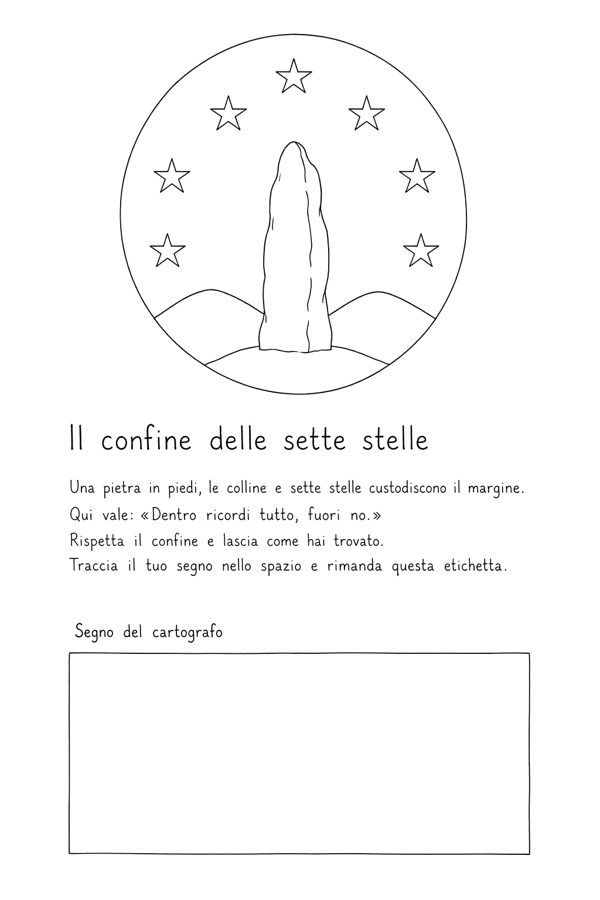

[9] collect: L’atlante riceve il segno



--- SENT: synthetic handwriting ---
The same sheet of paper, now filled in by a teenager with a blue ballpoint pen: untidy, slanted, not always on the line, a word crossed out somewhere.
Answer what the page asks, in Italian, briefly and in your own words — the way somebody of thirteen would, not the way a form would. Where there is a box to draw in, draw something rough.
Change nothing that is already printed on the page: not the title, not the lines, not the drawing. Add only what a person would have added, and leave the paper the same size.
Write only on the FIRST image. The other 3 images are sheets already on the table. Use their content when the first sheet refers to them. Return only the first sheet, with the added handwriting.


--- RETURNED: synthetic handwriting (43.429 s) ---


<529499 bytes>


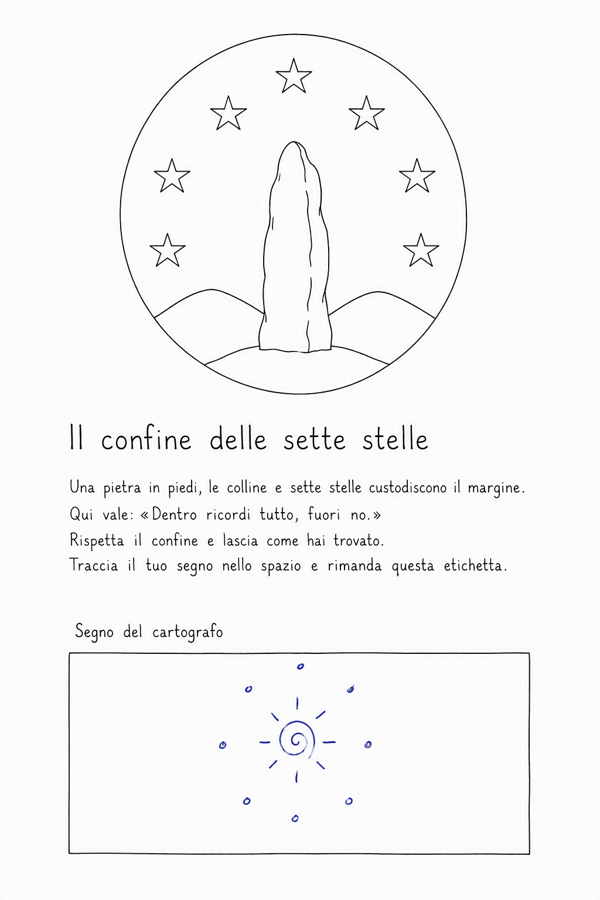


--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (4.19 s) ---


{"written":true,"same_sheet":true,"describes":["a blue spiral inside a circle with eight short rays in the lower box","eight small blue circles arranged around the central symbol"]}


[10] close: Accanto alla mappa



--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (2.177 s) ---


{"written":false,"same_sheet":true,"describes":[]}


{
  "status": "concluded",
  "reason": "",
  "built_from": {
    "form": "label-every-line-you-draw",
    "move": "one-fact-that-changes-what-was-already-read"
  },
  "blank_reading": {
    "written": false,
    "same_sheet": true,
    "describes": [],
    "read_at": 1789477873.0059588,
    "degraded": false,
    "metadata": {
      "read_by": "page_reader",
      "request_id": "rq_6856eb3d",
      "latency_s": 2.17
    }
  },
  "reading_in_continuation_prompt": true,
  "continuations": 3,
  "seconds": 643.734
}
Outcome: concluded 
Cell elapsed: 643.9 s
Artifacts: officina\runs\001-material-correspondence-20260915T131106126755Z


In [4]:
from research.workbench import live_activity


def seen(png: bytes) -> None:
    with Picture.open(io.BytesIO(png)) as picture:
        picture.thumbnail((620, 900))
        preview = io.BytesIO()
        picture.save(preview, format='PNG')
    display(Image(data=preview.getvalue()))


began = time.perf_counter()
try:
    RESULT = await live_activity(RUN, ARGS, show=seen)
    print('Outcome:', RESULT.status, RESULT.reason)
finally:
    print(f'Cell elapsed: {time.perf_counter() - began:.1f} s')
    print('Artifacts:', RUN.relative_to(ROOT))

## Transcript and Verification

The transcript distinguishes display messages, generated paper, returned marks and continuations. The checks count what this run actually did, rather than planned moments.

In [5]:
EXPERIENCE = json.loads((RUN / 'experience.json').read_text(encoding='utf-8'))
VERIFICATION = json.loads((RUN / 'verification.json').read_text(encoding='utf-8'))
WALK = json.loads((RUN / 'walk.json').read_text(encoding='utf-8'))
CALLS = json.loads((RUN / 'calls.json').read_text(encoding='utf-8'))
display(Markdown('### ' + EXPERIENCE['title']))
print(EXPERIENCE['overview'])
print(EXPERIENCE['script'])
for number, event in enumerate(WALK['events'], 1):
    print(f"\n{number}. {event['act']} / {event['moment']}")
    print('\n'.join(event['lines']))
    if 'reading' in event:
        print('Synthetic return:', json.dumps(event['reading'], ensure_ascii=False))
    if 'continuation' in event:
        print('Continuation received:', len(event['continuation']['moments']), 'moments')
returns = [event for event in WALK['events'] if event.get('reading', {}).get('written')]
CHECKS = {
    'concluded': WALK['status'] == 'concluded',
    'multiple_returns': len(returns) >= 2,
    'multiple_sheets_within_ceiling': 2 <= len(WALK['pages']) <= ARGS['sheets'],
    'continuation_received': VERIFICATION['continuations'] >= 1,
    'reading_reaches_prompt': VERIFICATION['reading_in_continuation_prompt'],
    'blank_control': not VERIFICATION['blank_reading']['written']
        and not VERIFICATION['blank_reading']['degraded'],
    'no_fallback': not any(event.get('status') == 'fallback' for event in WALK['events']),
}
print(json.dumps({
    'checks': CHECKS, 'sheets': len(WALK['pages']), 'written_returns': len(returns),
    'measured_seconds': VERIFICATION['seconds'],
    'declared_minutes': WALK['declared_minutes'],
}, indent=2))
assert all(CHECKS.values()), CHECKS
print('PASS: complete synthetic multi-exchange game')

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x000001731697D450>


### L’atlante dei Nove Margini

Collega nove luoghi inventati, etichetta ogni legame e decide quale resta più isolato; le risposte successive trasformano la stessa mappa. La stampante consegna una carta, poi due fogli che sviluppano i dettagli emersi e una tavola finale. Alla fine restano una mappa annotata e la sua etichetta d’atlante. Non serve altro oltre a carta e matita. Le linee incrociate possono rendere la mappa visivamente affollata.
THE WORLD. I Nove Margini sono nove luoghi di una città immaginaria: una lanterna spenta, una serra aperta, un ponte cieco, un pozzo sonoro, un archivio umido, una scala tronca, un forno freddo, un cortile obliquo e un osservatorio scoperto. Tutti i luoghi e i loro rapporti sono fittizi. L’oggetto di lavoro è una carta vista dall’alto, sulla quale ogni linea diventa un’affermazione sul rapporto fra due luoghi. THE WAY IN. La stampante consegna la Carta dei Nove Margini. La matita è sul tavolo. Il primo gesto è tracciare sulla carta una linea fra due figure e scrivere due parole 

## Call Record

Durations are measured wall-clock seconds per logical call. SDK retries and Content Safety requests are not separate rows, so this is not a billing ledger. Physical legibility, handling, photography, delivery waits and comprehension still require a real afternoon.

In [6]:
for number, call in enumerate(CALLS, 1):
    print(f"{number:2} {call['seconds']:8.1f} s {call['status']:6} {call['purpose']}")
print('Artifacts:', RUN.relative_to(ROOT))
print('Notebook iteration:', ITERATION)
print('Prompt fingerprint:', FINGERPRINT)

 1     16.3 s ok     choosing what to build an afternoon out of
 2     98.7 s ok     devising an afternoon
 3     20.4 s ok     repairing a refused afternoon
 4     47.2 s ok     drawing a map
 5     43.9 s ok     synthetic handwriting
 6     10.7 s ok     reading a page against its blank
 7     55.9 s ok     continuing aftn-e92c6455 after map-return
 8     40.3 s ok     drawing a notebook
 9     46.9 s ok     synthetic handwriting
10      6.7 s ok     reading a page against its blank
11     53.0 s ok     continuing aftn-e92c6455 after boundary-return
12     27.2 s ok     drawing a dossier
13     45.4 s ok     synthetic handwriting
14      5.2 s ok     reading a page against its blank
15     47.4 s ok     continuing aftn-e92c6455 after emblem-return
16     21.4 s ok     drawing a label
17     43.4 s ok     synthetic handwriting
18      4.2 s ok     reading a page against its blank
19      2.2 s ok     reading a page against its blank
Artifacts: officina\runs\001-material-correspondence

## Observed Result: 15 September 2026

The game, *L'atlante dei Nove Margini*, reached its explicit close after 10 executed moments, 4 generated sheets, 4 synthetic written returns and 3 model-generated continuations. The final display says: "La corrispondenza è conclusa." All six code cells completed without errors and all acceptance checks passed. The untouched-page control was blank and not degraded.

The notebook executor measured 655.8 seconds. The model-path verification measured 643.734 seconds, including the blank-page control. The executed moments declare 83 minutes; those minutes were not waited out or measured with a person.

The run is retained in [its artifact directory](runs/001-material-correspondence-20260915T131106126755Z/verification.json). It contains the original plan, full-size printed and marked images, prompts, timings and complete continuation documents inside the walk. The recorder used by this run stored some text payloads as length summaries in calls.json; the corresponding parsed continuations remain in walk.json. The recorder was corrected for subsequent runs, with a regression test.

The first synthetic response wrote labels and circled the observatory but did not draw the requested connections. The next sheet reused "solo davvero" and developed a boundary around that observatory. Its illustration introduced places absent from the original map, including standing stones. The following response selected those stones, and later pages continued from that choice. This verifies that returned material changes the game, while also exposing visual continuity that needs further work. The synthetic writer also introduced a restart rule; this run does not establish that every participant-facing sentence preserves the intended freedom to stop.

This is a scanner-style comparison of generated originals and synthetically marked images. Physical photographs, perspective correction, device delivery, printing, waiting and comprehension remain untested. The whole-game sheet ceiling passed in this run; repeated continuations still receive the original approved plan rather than an accumulated execution history.